# Fractional Brownian Motion Parameter Estimation Using Periodogram Method

The periodigram method uses the fractional brownian noise power spectrum to estimate the Hurst, denoted by $H$. The power spectrum is the Fourier transform of the fractional brownian motion noise autocorrelation function. This relationship is called the Weiner-Khichnin theorem.</br>

Let $Z^H(t)$ denote a fractional path then fractional brownian noise is defined by,

$
\begin{align}
\Delta Z_k^H = Z^H(t_k) - Z^H(t_{k-1})
\end{align}
\tag{1}
$

where $t_k = k \Delta t$. It follows that,

$
\begin{align}
Z^H(n\Delta t) = \sum_{i=1}^n \Delta Z_k^H
\end{align}
\tag{2}
$

The autocovariance of fractional brownian noise is given by,

$
\begin{align}
\gamma^H_n = \text{Cov}[\Delta Z^H_t \Delta Z^H_{t+n}] = \frac{1}{2}\Delta t^{2H}[(n-1)^{2H} + (n+1)^{2H} - 2n^{2H}]
\end{align}
\tag{3}
$

Since $\text{Var}(\Delta Z_k^H) = \Delta t^{2H}$ the autocorrelation coefficient is defined by,</br>

$
\begin{align}
\rho^H_n = \frac{\gamma^H_n}{\Delta t^{2H}} = \frac{1}{2}[(n-1)^{2H} + (n+1)^{2H} - 2n^{2H}]
\end{align}
\tag{4}
$

From the Weiner-Khichnin theorem the power spectrum is given by,</br>

$
\begin{align}
\hat{\rho}^H_\omega = \frac{1}{2} \int_{-\infty}^{\infty} \rho^H_n e^{-i \omega n} dn
\end{align}
\tag{5}
$

It can be shown that fir $\omega \gg 1$,

$
\begin{align}
\hat{\rho}^H_\omega \approx C\lvert \omega \rvert^{1 - 2H}
\end{align}
\tag{6}
$

where $C$ is independent of $\omega$. It follows that $H$ can be determined by using OLS on $\hat{\rho}^H_\omega$ as a< function of $\omega$.

## Imports

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import fbm, stats
from lib.plots import periodogram, curve, PlotType

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
npts = 2**10

## Power Spectrum Simulation H=0.8

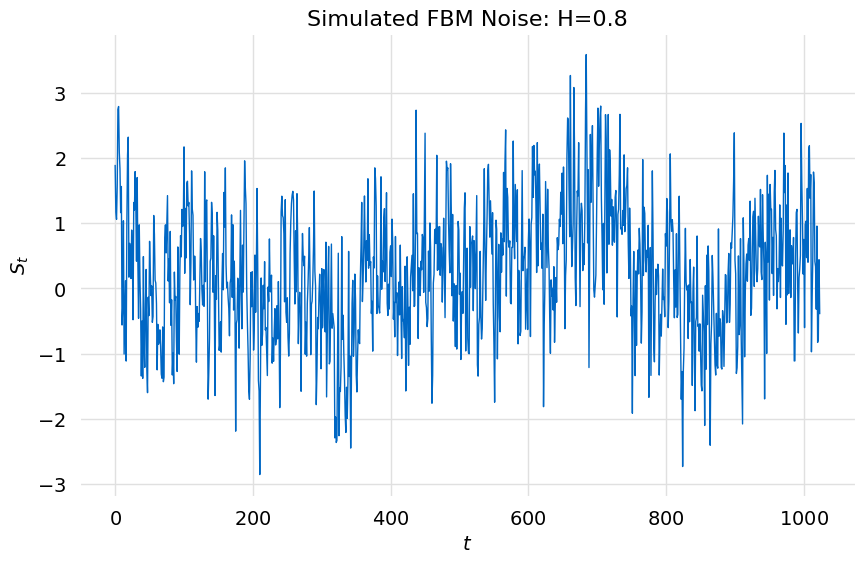

In [3]:
H = 0.8
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

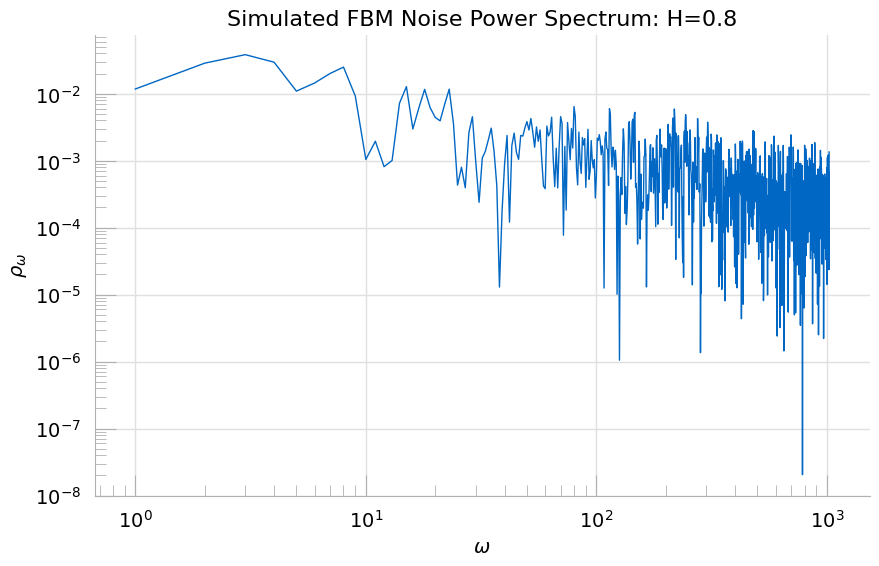

In [4]:
freq, ps = stats.compute_pspec(t, fbm_noise)

title = f"Simulated FBM Noise Power Spectrum: H={H}"
curve(ps, freq, lw=1, title=title, xlabel=r"$\omega$", ylabel=r"$\rho_\omega$", plot_axis_type=PlotType.LOG)

In [5]:
report, results = fbm.compute_H_estimate_periodogram(freq, ps)
report.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.218
Model:                            OLS   Adj. R-squared:                  0.217
Method:                 Least Squares   F-statistic:                     285.0
Date:                Sun, 23 Jul 2023   Prob (F-statistic):           1.39e-56
Time:                        11:58:09   Log-Likelihood:                -898.17
No. Observations:                1023   AIC:                             1800.
Df Residuals:                    1021   BIC:                             1810.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.5824      0.111    -14.223      0.000      -1.801      -1.364
x1            -0.7189      0.043    -16.882      0.000      -0.802      -0.635
==============================================================================
Omnibus:                      280.054   Durbin-Watson:                   1.386
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              870.728
Skew:                          -1.342   Prob(JB):                    8.39e-190
Kurtosis:                       6.636   Cond. No.                         18.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [6]:
results.dict

{'est_model': 'OLS_SING_VAR',
 'param': {'Estimate': -0.7188830003859942,
  'Error': 0.04258266669162137,
  'Estimate Label': None,
  'Error Label': None},
 'const': {'Estimate': -1.5824049508389118,
  'Error': 0.11125644065906887,
  'Estimate Label': None,
  'Error Label': None},
 'r2': 0.21822588440416146,
 'transform': {'model': '$C\\omega^{1 - 2H}$',
  'param': {'Estimate': 0.8594415001929971,
   'Error': 0.021291333345810685,
   'Estimate Label': '$\\hat{Η}$',
   'Error Label': '$\\sigma_{\\hat{Η}}$'},
  'const': {'Estimate': 0.026157428637923027,
   'Error': 0.002910182407048912,
   'Estimate Label': '$\\hat{C}$',
   'Error Label': '$\\sigma_{\\hat{C}}$'}}}

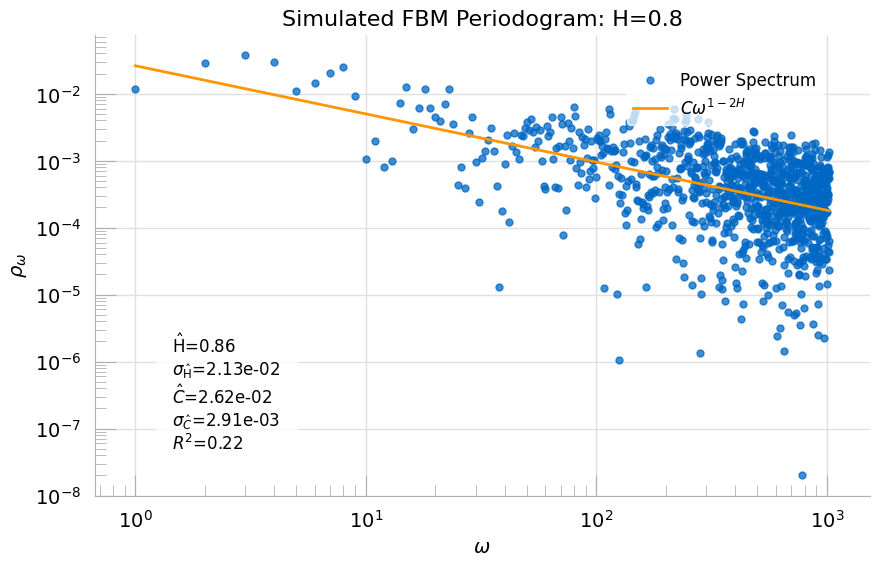

In [7]:
periodogram(ps, results, freq, title=f"Simulated FBM Periodogram: H={H}")

## Power Spectrum Simulation H=0.3

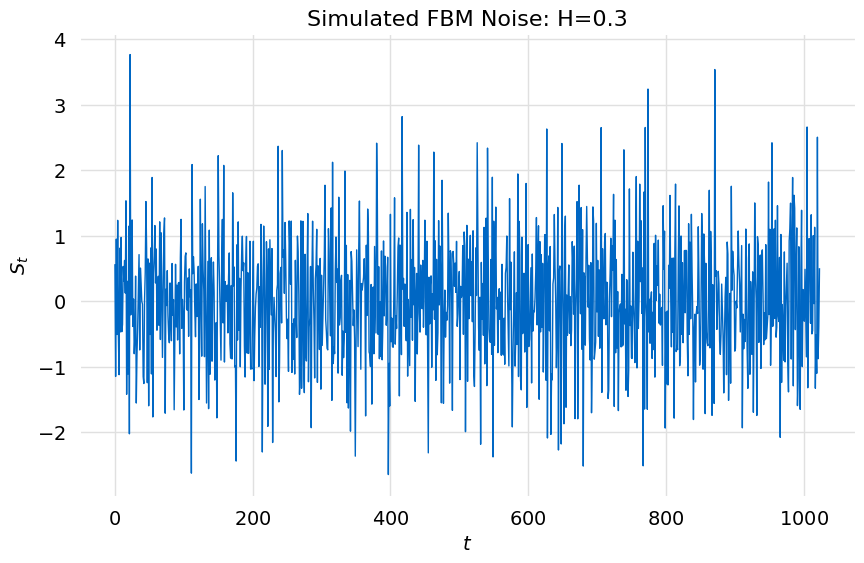

In [8]:
H = 0.3
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

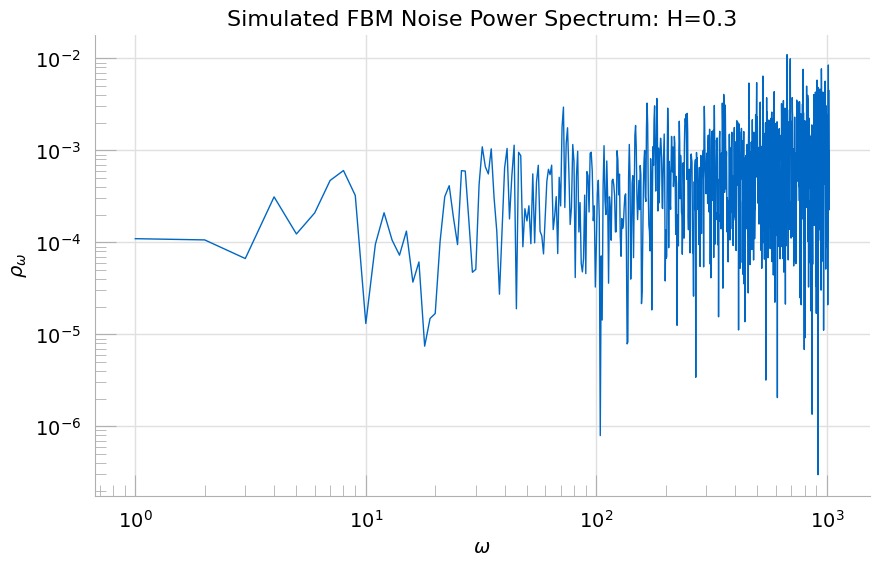

In [9]:
freq, ps = stats.compute_pspec(t, fbm_noise)

title = f"Simulated FBM Noise Power Spectrum: H={H}"
curve(ps, freq, lw=1, title=title, xlabel=r"$\omega$", ylabel=r"$\rho_\omega$", plot_axis_type=PlotType.LOG)

In [10]:
report, results = fbm.compute_H_estimate_periodogram(freq, ps)
report.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     84.63
Date:                Sun, 23 Jul 2023   Prob (F-statistic):           1.98e-19
Time:                        11:58:10   Log-Likelihood:                -877.78
No. Observations:                1023   AIC:                             1760.
Df Residuals:                    1021   BIC:                             1769.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.3009      0.109    -39.436      0.000      -4.515      -4.087
x1             0.3840      0.042      9.199      0.000       0.302       0.466
==============================================================================
Omnibus:                      195.915   Durbin-Watson:                   1.443
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              428.717
Skew:                          -1.064   Prob(JB):                     8.04e-94
Kurtosis:                       5.351   Cond. No.                         18.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [11]:
results.dict

{'est_model': 'OLS_SING_VAR',
 'param': {'Estimate': 0.38399299158092975,
  'Error': 0.04174206732417682,
  'Estimate Label': None,
  'Error Label': None},
 'const': {'Estimate': -4.300897711674228,
  'Error': 0.10906019272750032,
  'Estimate Label': None,
  'Error Label': None},
 'r2': 0.07654041925991106,
 'transform': {'model': '$C\\omega^{1 - 2H}$',
  'param': {'Estimate': 0.30800350420953515,
   'Error': 0.02087103366208841,
   'Estimate Label': '$\\hat{Η}$',
   'Error Label': '$\\sigma_{\\hat{Η}}$'},
  'const': {'Estimate': 5.001523207683292e-05,
   'Error': 5.454670849610054e-06,
   'Estimate Label': '$\\hat{C}$',
   'Error Label': '$\\sigma_{\\hat{C}}$'}}}

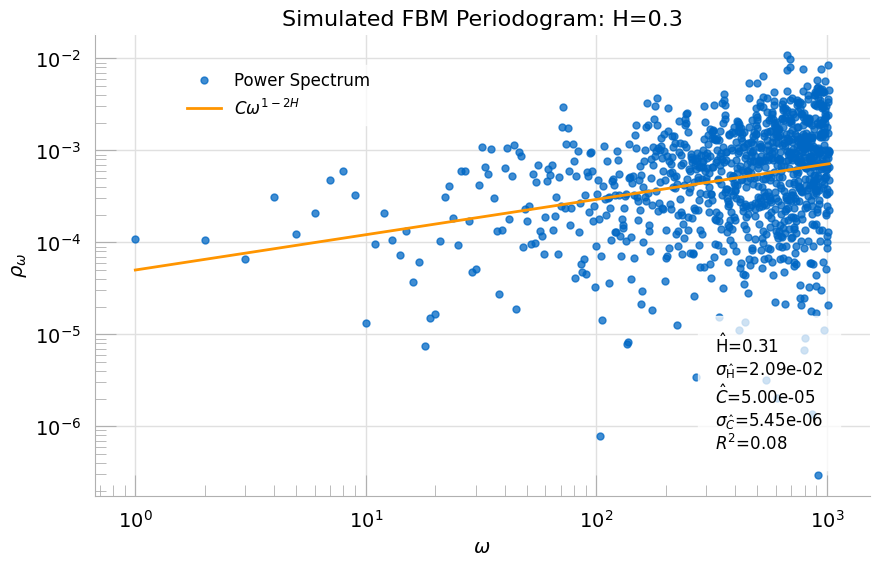

In [12]:
periodogram(ps, results, freq, title=f"Simulated FBM Periodogram: H={H}")